In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

ANALYSIS_DIR = os.getcwd() # current_directory
PROJECT_DIR = os.path.dirname(ANALYSIS_DIR)
DATA_DIR = os.path.join(PROJECT_DIR,"data")
TYPOLOGY_DIR = os.path.join(PROJECT_DIR,"typology_coding")
POLITICIAN_NAME = "Xi Jinping"  #can be changed 
SAFE_NAME = POLITICIAN_NAME. replace(" ", "_")
POLITICIAN_DIR = os.path.join (DATA_DIR, SAFE_NAME)

#print(ANALYSIS_DIR)

CSV = os.path.join(TYPOLOGY_DIR, "Xi_Jinping_Definitive.csv")    

df = pd.read_csv(CSV)
df.columns = df.columns.str.strip()

North American sources and Others

In [19]:
# North American sources set
na_sites = {
    "news.google.com",
    "reuters.com",
    "washingtonpost.com",
    "cnn.com",
    "thestar.com",
    "nationalpost.com",
    "globalnews.ca",
    "theglobeandmail.com",
    "nypost.com",
    "nytimes.com",
    "nbcnews.com",
    "cbc.ca",
    "cbsnews.com",
    "foxnews.com",
    "usatoday.com",
    "salon.com",
    "theatlantic.com",
    "abcnews.go.com",
    "vox.com",
    "cnbc.com",
    "jamestown.org",
    "today.com",
    "chinadigitaltimes.net",
    "breitbart.com"
}

# Determine all sources and other sources
all_sources = set(df["source"].unique())
other_sites = sorted(all_sources.difference(na_sites))

# Filter df
df_na = df[df["source"].isin(na_sites)]
df_other = df[df["source"].isin(other_sites)]

In [20]:
# Color mapping
color_map = {
    "Negative": "red",
    "Positive": "green",
    "Neutral": "grey"
}

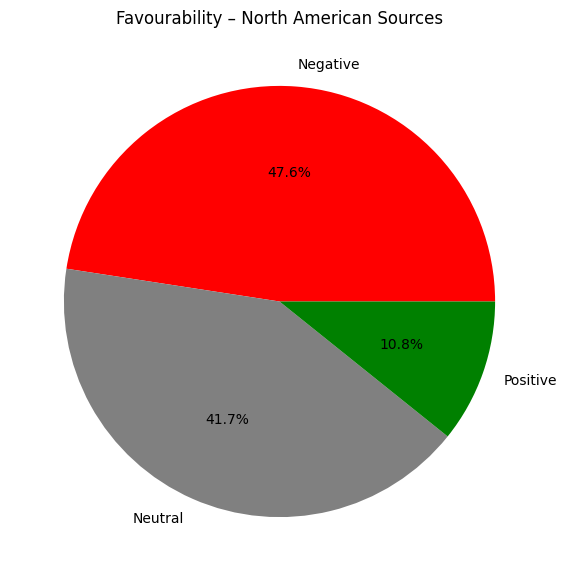

In [21]:
# ---- Plot - NA favourability ----
na_counts = df_na["Definitive_Fav"].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(
    na_counts,
    labels=na_counts.index,
    autopct='%1.1f%%',
    colors=[color_map.get(label, "grey") for label in na_counts.index]
)
plt.title("Favourability – North American Sources")

#Save to images folder 
plt.savefig("../images/aFavourability_NA_Sources.png", dpi=300, bbox_inches='tight')

plt.show()

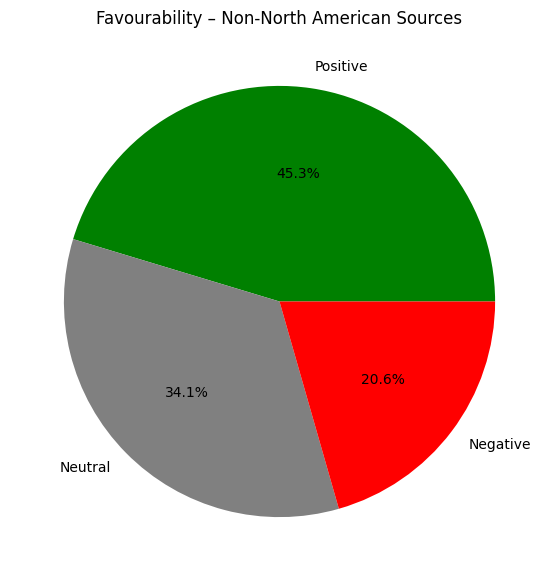

In [22]:
# ---- Plot - NA favourability ----
other_counts = df_other["Definitive_Fav"].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(
    other_counts,
    labels=other_counts.index,
    autopct='%1.1f%%',
    colors=[color_map.get(label, "grey") for label in other_counts.index]
)
plt.title("Favourability – Non-North American Sources")

#Save to images folder 
plt.savefig("../images/aFavourability_Other_Sources.png", dpi=300, bbox_inches='tight')

plt.show()